# SCEM Coursework

Written by : Revalda Putawara (ey24622@bristol.ac.uk) 
This Notebook was created to fulfill the Coursework for EMATM0061 - Statistical Computing and Empirical Methods (SCEM) Coursework. (Teaching Block 1 2024/2025)

For this assignment, I will construct a Data Science report, in which I will choose Example task 2 and explore it in depth. I will investigate a particular method of supervised learning and demonstrate the depth of my understanding of it.

## Load related packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report, roc_curve
from sklearn.model_selection import GridSearchCV

In [2]:
from sklearn.ensemble import RandomForestClassifier

In [3]:
import numpy as np

In [4]:
from IPython.display import Markdown as md

In [5]:
# setting seed number for reproducibility
np.random.seed(2030)
RANDOMSTATE = 2030

# (Question 1)

Decision Trees / Classification and Regression Trees (CART) are one of the machine learning algorithms that can be utilized to solve regression and classification problem. Decision Trees emerge as one of the best ML algorithms due to its interpretability and speed of construction, ability to include both numeric and categorical predictor, and perform internal feature selection as part of its algorithm. The drawback of Decision Trees lies on how its predictive power that is comparably low to other algorithms, and its tendency to overfit the training data. Bootstrap aggregation (bagging) can be done to countermeasure decision tree’s drawbacks.

![Decision Tree](img/Decision_Tree.jpg)

Example of a Decision Tree

Source: https://en.wikipedia.org/wiki/Decision_tree_learning

One of a modification towards bagging that can solve decision tree’s drawbacks of inaccuracy is **Random Forests**. Random Forests **underlying principle** is by averaging many decision trees fed by bootstrapped data. These bootstrapped decision trees have a low bias among them, due to its nature to fit the training data too well. On the contrary, the variance between those decision trees is quite large due to the different sample that was generated by the bootstrapping mechanism.  Therefore, to reduce this variance we can use the process of averaging those smaller decision trees, in order to get the best predictor resulted from the randomly generated bootstrapped trees, thus the algorithm is called “Random Forest”.

One of the **assumptions**  on using Random Forest is that the prediction of the individual smaller trees have very low correlations among them. As the prediction between these smaller trees are identically distributed (i.d.), the variance of the average is:

$$ \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

$\rho$ represents pairwise correlation between individual prediction. To achieve the benefit of averaging, we need to make $\rho$ to be as small as possible. This will simplify the equation into $\frac{1}{B} \sigma^2$. This purpose can be achieved by the tree-growing step that utilizes random selection of predictor variables. 

**How the algorithm works** can be explained as follows:

1.	For $b=1$ to $B$, do these steps:

    a.	Draw a bootsrap sample $Z^{*}$ of size $N$ from the training data.

    b.	Create a random-forest tree $T_{b}$ to the bootstrapped data. For each of the terminal node, select $m$ variables at random from the $p$ variables. Pick the best split-point among $m$. Then, split the terminal node into two nodes. Do this steps recursively until node size $n_{min}$ is reached. 

2.	Output the ensemble of trees ${Tb}_1^B$ 

The randomness of selecting m variables from p variables reduces the variance trees created from bagging process. 

To create a **prediction on a new test data**, we do the following depending on the problem that we want to solve:


- For regression, the prediction is the average of all bootstrap trees. 

$$\hat{f}_{rf}^{B}(x)=\frac{1}{B} \Sigma_{b=1}^B \ T_b(x)$$

- For classification, the prediction of random forest is the class that is winning the majority vote of all bootstrap trees.

$$\hat{C}_{rf}^{B}(x)=majority \ vote \{\hat{C}_{b}(x)\}_{1}^{B}$$

Illustration of Random Forest Algorithm

![Random Forest Algorithm](img/random-forest-algorithm.png)

Source: https://www.javatpoint.com/machine-learning-random-forest-algorithm

# (Question 2)

## Question 2.a. Load the Dataset and Describe

For this report, I will use [Loan Approval Classification Dataset](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data) from Kaggle. This dataset is a synthetic financial data containing 45000 records and 14 variables. 

In [6]:
# load the data from csv as a dataframe
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [7]:
# convert some columns type to category, age to integer
catcols = ["person_gender",
           "person_education",
           "person_home_ownership",
           "loan_intent",
          "previous_loan_defaults_on_file",
          "loan_status"]
df[catcols] = df[catcols].astype('category')
df["person_age"] = df["person_age"].astype('int64')

## Question 2.b. Making sure the data is appropriate

In [8]:
# Statistical Summary of the Data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00


Based on the dataframe info above, we can see that there are **more than 1 categorical column**. Our target variable is loan_status column.

## Question 2.c. Type for each variable

In [9]:
# Information of the data
# Please do note that there are no MISSING VALUES in the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   person_age                      45000 non-null  int64   
 1   person_gender                   45000 non-null  category
 2   person_education                45000 non-null  category
 3   person_income                   45000 non-null  float64 
 4   person_emp_exp                  45000 non-null  int64   
 5   person_home_ownership           45000 non-null  category
 6   loan_amnt                       45000 non-null  float64 
 7   loan_intent                     45000 non-null  category
 8   loan_int_rate                   45000 non-null  float64 
 9   loan_percent_income             45000 non-null  float64 
 10  cb_person_cred_hist_length      45000 non-null  float64 
 11  credit_score                    45000 non-null  int64   
 12  previous_loan_defa

The type for each variables are as follows:
| Feature | Type |
| --- | --- |
| person_age | continuous |
| person_gender | binary |
| person_education | ordinal |
| person_income | continuous |
| person_emp_exp | continuous |
| person_home_ownership | categorical |
| loan_amt | continuous |
| loan_intent | categorical |
| loan_int_rate | continuous |
| loan_percent_income | continuous |
| cb_person_cred_hist_length | continuous |
| credit_score | continuous |
| previous_loan_defaults_on_file | categorical |
| loan_status | binary |

## Question 2.d. Describing dataset features and examples

Based on the data that we already had, we have **45000 records of data**. There are **13 feature variable and 1 target variable**. No missing data is observed from the dataset. 

These columns is not 100% ready to be fed to our Random Forests model. This is due to the fact that we have categorical and ordinal columns. These columns should be preprocessed with one-hot encoding and value mapping. This will transform the columns data type into continuous. This preprocessed data will make it easier for the model to fit into the training data. Below are the examples of **data before transformation**:

In [10]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [11]:
# Make list of categorical code and observe its unique values
category_cols = df.select_dtypes(exclude=["number","bool_","object_"]).columns.tolist()

for ccc in category_cols:
    print("Column Name : {}".format(ccc))
    print(list(df[ccc].unique()))
    print("=====")

Column Name : person_gender
['female', 'male']
=====
Column Name : person_education
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
=====
Column Name : person_home_ownership
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
=====
Column Name : loan_intent
['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
=====
Column Name : previous_loan_defaults_on_file
['No', 'Yes']
=====
Column Name : loan_status
[1, 0]
=====


For our categorical data, we should transform the column by using one hot encoding. For our ordinal data, we should transform them by mapping the category to integer. Here is our **data after transformation/preprocessing:**

In [12]:
# one hot encoding for categorical columns
df = pd.get_dummies(df,columns = ['person_gender',
                                  'person_home_ownership',
                                 'loan_intent',
                                 'previous_loan_defaults_on_file',
                                 ], drop_first=True, dtype=int)

# map ordinal category to integer
education_level = {'High School':1,'Associate':2,'Bachelor':3,'Master':4,'Doctorate':5} 
df['person_education'] = df['person_education'].map(education_level) #map ordinal data from 1 to 5
df.head()

,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22,4,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,0,0,1,0,0,0,1,0,0
1,21,1,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,0,1,0,1,0,0,0,0,1
2,25,1,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,0,0,0,0,0,1,0,0,0
3,23,3,79753.0,0,35000.0,15.23,0.44,2.0,675,1,0,0,0,1,0,0,1,0,0,0
4,24,4,66135.0,1,35000.0,14.27,0.53,4.0,586,1,1,0,0,1,0,0,1,0,0,0


## Question 2.e. Problem that I will solve 

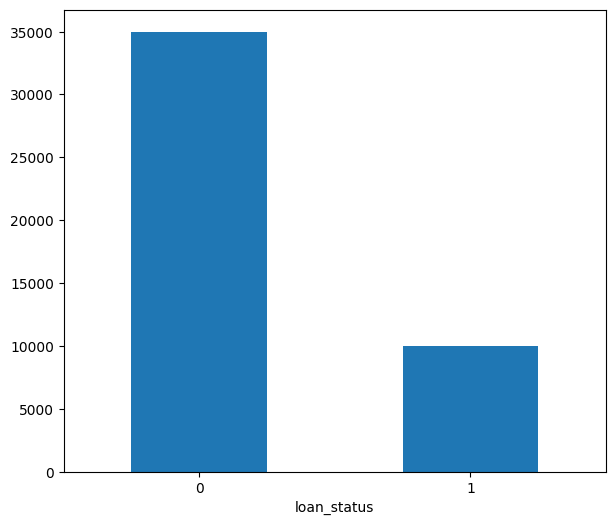

In [13]:
# see the count for each class
ax = df['loan_status'].value_counts().plot(kind='bar', figsize=(7, 6), rot=0)

The problem that I want to solve in this dataset is predicting whether **application of loan is approved / not approved**, reflected in *loan_status* column. Thus, the problem falls into a **Binary Classification problem**. Decision Trees can be used to solve this problem, by learning from the features and predict the corresponding target variable.

## Question 2.f. Train, Test, and Validation Split

For this earlier part of report, I will split data in **70:15:15** ratio for train:validation:test split.

In [14]:
# separate feature and target variable
X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

In [15]:
#Split Train:Val:Test in 70 : 15 : 15 ratio
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RANDOMSTATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOMSTATE)

In [16]:
print("The number of rows for training data: {}\nThe number of rows for validation data: {}\nThe number of rows for test data: {}\n".format(len(y_train),len(y_val),len(y_test)))

The number of rows for training data: 31500
The number of rows for validation data: 6750
The number of rows for test data: 6750



# (Question 3)

- explain the performance metric CLEARLY
- how performance varies on train and validation set
- compare the performance of models accross different sizes of training data

## Question 3.a Explaining the Model Performance Metric

One of the performance metric that is used for Binary Classification problem is Confusion Matrix. Confusion Matrix describes how well our model predict the respective classes. Confusion Matrix can be illustrated as follows:

![Confusion Matrix](img/Confusion-Matrix.png)

Source : https://www.analyticsvidhya.com/blog/2021/07/metrics-to-evaluate-your-classification-model-to-take-the-right-decisions/

In the problem that we are going to solve in this Data Science Report:
- True Positive (TP) means that we approve the loan for those that is worthy for the loan ($\hat{y}=1$ and $y=1$)
- True Negative (TN) means that we reject the loan for those that is not worthy for the loan ($\hat{y}=0$ and $y=0$)
- False Positive (FP) means that we approve the loan for those that is not worthy for the loan ($\hat{y}=1$ and $y=0$). This is Type I Error.
- False Negative (FN) means that we reject the loan for those that is worthy for the loan ($\hat{y}=0$ and $y=1$). This is Type II Error.

In our problem , **False Positive and False Negative is assumed to have a similar harm** for the company.  The False Positive poses the risk of a loan default by the customer, while the False Negative will damage our reputation in not giving loans to those that can actually pay them back. If either one of FP and FN is the focus of our problem, we can use Precision or Recall as our Model Performance Metrics. Because it's not the case in our problem, we can shift our focus on **how well the model is giving the loan** to the customer. Based on this statement, we can focus our model for the True Positive (Sensitivity) and False Positive (1-Specifity) rate. To do that, we can use the help of Receiver Operating Characteristic Curve (ROC).

![ROC Curve](img/auc_1-0.png)
Illustration of ROC and AUC of a hypothetically perfect model.

Source : https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc

**ROC is plotted** by calculating true positive rate (TPR) and false positive rate (FPR) for every threshold. With $\hat{y}$ representing the predicted probability for positive (1) class, and \tau as the threshold value ($0\le \tau \le 1$), the predicted class $\hat{y}_{\text{class}}$ can be stated as:
$$
\hat{y}_{\text{class}} = 
\begin{cases} 
1, & \text{if } \hat{y} \geq \tau \\
0, & \text{if } \hat{y} < \tau 
\end{cases}
$$

While performance metric of accuracy only manage to capture model performance at 1 threshold value, ROC Curve can capture model performance accross multiple threshold value, thus giving us a bigger picture on how well the model performed in multiple scenarios. This will give us a better model performance if later we want to shift the threshold value (default value of $\tau = 0.5$). ROC Curve can plot the value of TPR and FPR for each confusion matrix of each threshold value, giving us as the Data Scientist an insight on how the trade-off between TPR and FPR is for each threshold.

To compare which model is better compared to others, we can calculate **Area Under Curve (AUC)** and compare them accross different models. AUC represents the probability of the model correctly classify the positive sample as positive class rather than as negative class. Since we want higher TPR for our classification model (given its FPR rate tradeoff), we should choose the model that give **highest Area Under Curve**. 

Suppose that we have $N$ models. Each models are represented as $M_1, \dots, M_N$. Each model is associated with AUC Score $AUC(M_i)$. Our best model can be stated as:

$$
M_{best} = \arg\max_{i \in \{1, 2, \ldots, N\}} \text{AUC}(M_i)
$$

In this example, we will prefer model B below instead of model A, as it yield higher AUC score.


A | B
- | - 
![ROC 0.65](img/auc_0-65.png) | ![ROC 0.93](img/auc_0-93.png)

source : https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc

To calculate the ROC AUC score, we will utilize **sklearn.metrics.roc_auc_score**. We can plot the ROC Curve with **sklearn.metrics.roc_curve**.

In [17]:
def plot_auc_roc_curve(roc_auc_score, y_true, y_pred_proba):
    """
    this function is used to plot the roc curve
    """

    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc_score))
    baseline = [0 for i in range(len(y_true))]
    baseline_fpr, baseline_tpr, thresholds = roc_curve(y_true, baseline)
    plt.plot(baseline_fpr, baseline_tpr, linestyle='--')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive rate')
    plt.legend(loc='best')

Additional Note : We are assuming that the dataset that we are working on is balanced, as in, the ratio of one smaller class to another class (in our problem, 1 and 0 of loan status), is not smaller that 0.1. **If the class is imbalanced**, we can use **Precision-Recall Curve - Area Under Curve (PR AUC)** as our Performance Metrics.

## Question 3.b. Model Performance accross different training data size

For our classification problem we will use [sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) class. In this scenario, we will create the training, validation, and test dataset. We will vary the ratio of training data $r$, then the rest of the data will split evenly among the validation and test data. In this section, we will vary the training dataset ratio from 0.5, 0.6, 0.7, 0.8 and 0.9. We assume that every other Random Forest variable is fixed. To ensure reproducibility, we set RANDOM STATE = 2030 for all models.

In [18]:
# create a dataframe to save the experiment result
training_data_experiment_result = pd.DataFrame(columns=["Train Size","ROC AUC train","ROC AUC val"])

# loop for the varying training dataset size / ratio
for r in range(50,100,10):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=r/100, random_state=RANDOMSTATE)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOMSTATE)
    # scale numerical data in each feature split with robust scaler
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.fit_transform(X_test)
    model = RandomForestClassifier(random_state=RANDOMSTATE)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)
    model_val_roc_auc_score = roc_auc_score(y_val, y_val_pred)

    new_row = {"Train Size": r/100, "ROC AUC train": model_train_roc_auc_score, "ROC AUC val": model_val_roc_auc_score,}
    #training_data_experiment_result = training_data_experiment_result.append(new_row, ignore_index=True)
    training_data_experiment_result = pd.concat([training_data_experiment_result, pd.DataFrame([new_row])], ignore_index=True)
    print("Successfully get result for train data size : {}".format(r/100))

C:\Users\Revalda Putawara\AppData\Local\Temp\ipykernel_17984\3729189719.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  training_data_experiment_result = pd.concat([training_data_experiment_result, pd.DataFrame([new_row])], ignore_index=True)


Successfully get result for train data size : 0.5
Successfully get result for train data size : 0.6
Successfully get result for train data size : 0.7
Successfully get result for train data size : 0.8
Successfully get result for train data size : 0.9


In [19]:
training_data_experiment_result

,Train Size,ROC AUC train,ROC AUC val
0,0.5,1.0,0.869430
1,0.6,1.0,0.866424
2,0.7,1.0,0.862033
3,0.8,1.0,0.860945
4,0.9,1.0,0.857145


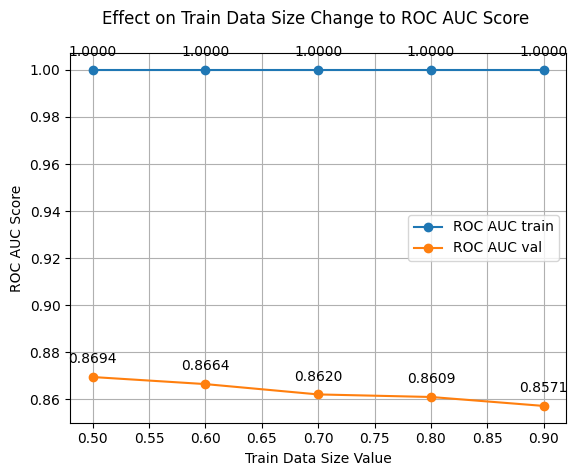

In [20]:
#plot the experiment result
training_data_experiment_result.plot(x="Train Size", y=["ROC AUC train", "ROC AUC val"],marker="o")

for cols_show in ["ROC AUC train", "ROC AUC val"]:
    for x_coord,y_coord in zip(training_data_experiment_result["Train Size"],training_data_experiment_result[cols_show]):
    
        label = "{:.4f}".format(y_coord)
    
        plt.annotate(label,
                     (x_coord,y_coord),
                     textcoords="offset points",
                     xytext=(0,10),
                     ha='center')
plt.title("Effect on Train Data Size Change to ROC AUC Score \n")
plt.xlabel("Train Data Size Value")
plt.ylabel("ROC AUC Score")
plt.grid()
plt.show()

Based on our experiment above, there are some observations:
- the model varies its AUC Score on the validation dataset
- the AUC score is **not varying on the training dataset**, demonstrating **robustness of the model against training data size**.
- The model performed best when the training dataset ratio $r=0.5$ with its $AUC(M_i)=0.8694$ on validation dataset.
- The model decreases in AUC score as the training dataset increases. It might be due to the fact that while the training dataset size is increasing, the validation dataset is decreasing, providing higher sample to validate for low training data size.


We can also calculate the AUC Score on the test data to see how the model performed on it.

In [21]:
# split data with train:val:test ratio of 50:25:25
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=50/100, random_state=RANDOMSTATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOMSTATE)
# scale numerical data in each feature split with robust scaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.fit_transform(X_test)
model = RandomForestClassifier(random_state=RANDOMSTATE)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=2030)

In [22]:
#predict train val and test
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)
y_val_pred_proba = model.predict_proba(X_val)
model_val_roc_auc_score = roc_auc_score(y_val, y_val_pred)
model_test_roc_auc_score = roc_auc_score(y_test, y_test_pred)
model_test_roc_auc_score

np.float64(0.8605307675567013)

The AUC Score for the test dataset on training data set ratio $r=0.5$ is 0.8605. Next, below are the ROC Curve for our best model of training size $r=0.5$.

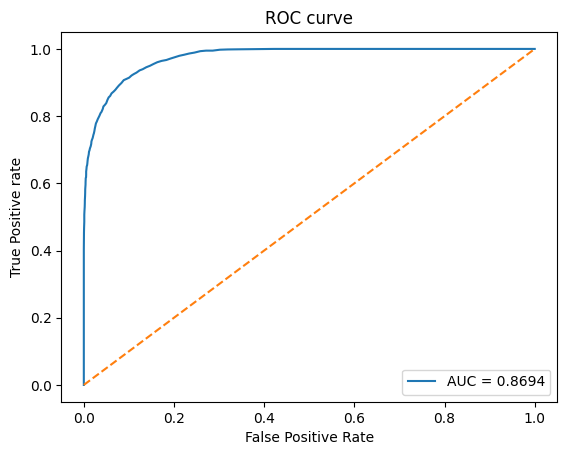

In [23]:
# ROC of our model
plot_auc_roc_curve(model_val_roc_auc_score, y_val, y_val_pred_proba[:,1])

# (Question 4)

- effect on varying a hyperparameter to the performance of the model, both for training data and validation data

## Hyperparameter tuning for parameter min_samples_split

Based on the documentation provided by the scikit-learn package developer : [sklearn.ensemble.RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), there are some hyperparameter that can be finetuned from Random Forest Classifier. Below are the default value for each parameter:

In [24]:
# see the list of tunable parameter of RandomForestClassifier
model = RandomForestClassifier()
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

One hyperparameter of my interest is the **min_samples_split** parameter. Based on its explanation from the provided documentation, min_samples_split represents the minimum number of samples required to split an internal node. For a node to be split, the algorithm will check first that there are adequate samples in the node to split. Assume that the number of samples in a node is notated as $n$ and min_samples_split is notated as $n_{min}$, if $n \ge n_{min} $ then the node can be splitted. If $n \lt n_{min} $, then the node will become a leaf node. The example below demonstrate a condition when $n_{min}=3$. Look at the nodes that can't be split, as its number of samples $n \lt n_{min}$.

![ROC 0.65](img/min_samples_split.jpg)

In this observation, we will have a dataset consisting of train, validation, and test dataset with a ratio of 70:15:15. We will observe the value of our performance metrics (AUC ROC Curve) for training and validation dataset by the effect of changing the hyperparameter min_samples_split. We vary the number of min_samples_split from 2 to 11.

In [25]:
#Split Train:Val:Test in 80 : 10 : 10 ratio
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.8, random_state=2030)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=2030)

# Create Robust Scaler for our features
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.fit_transform(X_test)

In [26]:
%%time

# create a dataframe to store our experiment result
hyperparameter_experiment_result = pd.DataFrame(columns=["Hyperparameter","ROC AUC train","ROC AUC val"])

# for loop to vary our min_samples_split from 2 to 11
for h in list(range(2,12,1)):
    model = RandomForestClassifier(random_state=RANDOMSTATE,
                              min_samples_split=h)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)
    model_val_roc_auc_score = roc_auc_score(y_val, y_val_pred)

    new_row = {"Hyperparameter": h, "ROC AUC train": model_train_roc_auc_score, "ROC AUC val": model_val_roc_auc_score,}
    #training_data_experiment_result = training_data_experiment_result.append(new_row, ignore_index=True)
    hyperparameter_experiment_result = pd.concat([hyperparameter_experiment_result, pd.DataFrame([new_row])], ignore_index=True)
    print("Successfully get result for hyperparameter : {}".format(h))

<timed exec>:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


Successfully get result for hyperparameter : 2
Successfully get result for hyperparameter : 3
Successfully get result for hyperparameter : 4
Successfully get result for hyperparameter : 5
Successfully get result for hyperparameter : 6
Successfully get result for hyperparameter : 7
Successfully get result for hyperparameter : 8
Successfully get result for hyperparameter : 9
Successfully get result for hyperparameter : 10
Successfully get result for hyperparameter : 11
CPU times: total: 5.83 s
Wall time: 9.07 s


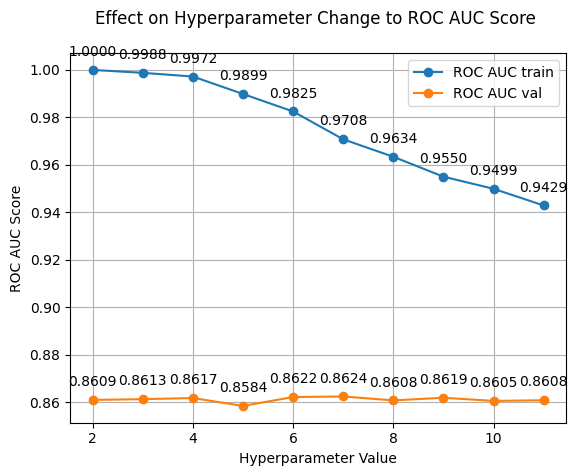

In [27]:
#plot our experiment result
hyperparameter_experiment_result.plot(x="Hyperparameter", y=["ROC AUC train", "ROC AUC val"],marker="o")

for cols_show in ["ROC AUC train", "ROC AUC val"]:
    for x_coord,y_coord in zip(hyperparameter_experiment_result["Hyperparameter"],hyperparameter_experiment_result[cols_show]):
    
        label = "{:.4f}".format(y_coord)
    
        plt.annotate(label,
                     (x_coord-2,y_coord),
                     textcoords="offset points",
                     xytext=(0,10),
                     ha='center',
                    )
plt.title("Effect on Hyperparameter Change to ROC AUC Score \n")
plt.xlabel("Hyperparameter Value")
plt.ylabel("ROC AUC Score")
plt.grid()
plt.show()

In [28]:
md("As we can see from the graph above: \n\
- The AUC ROC score for the train dataset decreases as the value of min_samples_split increase. This might come from the fact that the minimum sample for a terminal node is increasing, it became **harder for the model to fit** the data well as it's harder for the model to split when it's needed. \n \
- The AUC ROC score for the validation dataset seems not affected too much by the change of min_samples_split parameter value. The best model that we can have for the validation dataset is when the number of min_samples_split is {}. \n\n \
Then we can calculate the AUC ROC score for the test dataset:".format(hyperparameter_experiment_result.at[hyperparameter_experiment_result["ROC AUC val"].argmax(),"Hyperparameter"]))

As we can see from the graph above: 
- The AUC ROC score for the train dataset decreases as the value of min_samples_split increase. This might come from the fact that the minimum sample for a terminal node is increasing, it became **harder for the model to fit** the data well as it's harder for the model to split when it's needed. 
 - The AUC ROC score for the validation dataset seems not affected too much by the change of min_samples_split parameter value. The best model that we can have for the validation dataset is when the number of min_samples_split is 7. 

 Then we can calculate the AUC ROC score for the test dataset:

In [29]:
# create the model from our best hyperparameter
model = RandomForestClassifier(random_state=RANDOMSTATE,
                              min_samples_split=hyperparameter_experiment_result.at[hyperparameter_experiment_result["ROC AUC val"].argmax(),
                               "Hyperparameter"])
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)
model_test_roc_auc_score = roc_auc_score(y_test, y_test_pred)
model_test_roc_auc_score #show test roc auc score

np.float64(0.8663650166485726)

In [30]:
# show AUC ROC Score for test dataset
md("The AUC ROC Score for the test dataset is {:.4f}".format(model_test_roc_auc_score))

The AUC ROC Score for the test dataset is 0.8664

# (Question 5)

- choose hyperparameter and report its performance
- get a better understanding with cross-validation

For this experiment, we will:
- use **min_samples_split** as a varying hyperparameter, with a range of 2,...,11
- doing a cross-validation with k = 10
- as the validation set will be handled using cross-validation, we only split the dataset into a train:test split with a ratio of 70:30
- We are doing the cross validation with the help of **sklearn.model_selection.GridSearchCV** class.

![Cross Validation](img/grid_search_cross_validation.png)

Illustration of Cross Validation process

Source : [Scikit-Learn documentation on Cross Validation](https://scikit-learn.org/dev/modules/cross_validation.html#stratification)

In [31]:
#Split Train:Test in 80:20 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2030)

# Create Robust Scaler for our features
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [32]:
# define our k fold
k_cv = 10

# define grid for our hyperparameter
grid = {
    "min_samples_split" : list(range(2,12,1))
}

# define our random forest classifier model
model_for_grid = RandomForestClassifier(random_state=RANDOMSTATE)

# define our grid search
grid_search = GridSearchCV(estimator=model_for_grid, param_grid=grid, cv = k_cv, n_jobs = -1, verbose = 2, scoring = "roc_auc")

In [33]:
%%time

# fit our grid search to feature and label of training data
grid_search.fit(X_train, y_train)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
CPU times: total: 2.14 s
Wall time: 32.8 s


GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=2030),
             n_jobs=-1,
             param_grid={'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]},
             scoring='roc_auc', verbose=2)

In [34]:
# Create a dataframe to plot the mean_test_score and std_test_score
split_numbers = []
params_values = []
scores = []

# Extract the number of parameter settings
n_params = len(grid_search.cv_results_['param_min_samples_split'])

# Iterate over each split and parameter setting
for split in range(10):  # As we have k=10 splits
    for param_index in range(n_params):
        # Append split number
        split_numbers.append(split)
        
        # Append parameter value
        params_values.append(grid_search.cv_results_['param_min_samples_split'][param_index])
        
        # Append score
        score_key = f'split{split}_test_score'
        scores.append(grid_search.cv_results_[score_key][param_index])

# Create a DataFrame
df_cv_result = pd.DataFrame({
    'split_number': split_numbers,
    'params_value': params_values,
    'score': scores
})

# Display the first few rows of the DataFrame
#df_cv_result.head()

In [35]:
# df_cv_result.groupby("split_number").mean()

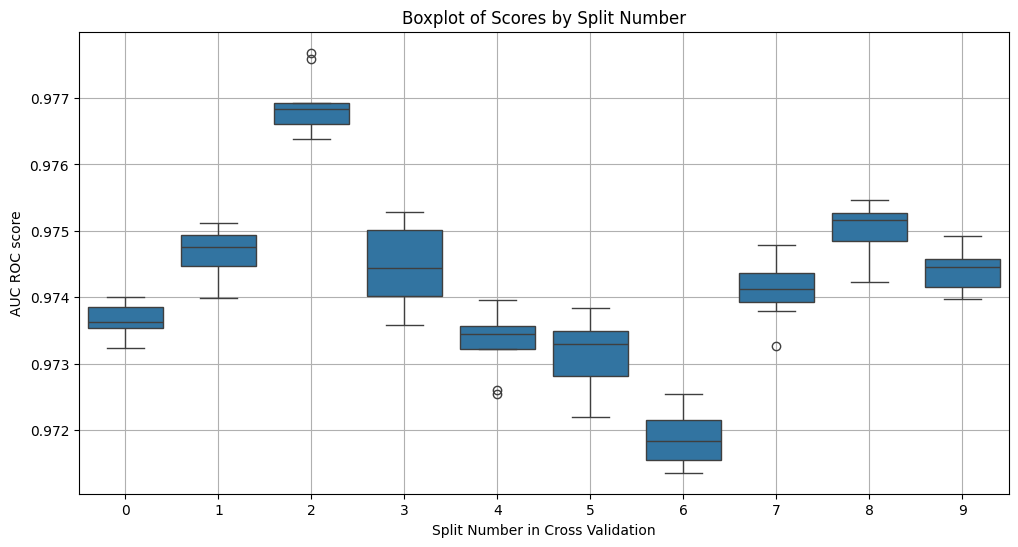

In [36]:
# Create a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='split_number', y='score', data=df_cv_result)

# Add titles and labels
plt.title('Boxplot of Scores by Split Number')
plt.xlabel('Split Number in Cross Validation')
plt.ylabel('AUC ROC score')
plt.grid()

# Show plot
plt.show()

Based on the AUC ROC Score Boxplot for each split, we can conclude that:
- As the AUC ROC Score does not vary much accross different splits, we can assume that our model is quite robust to the change of the dataset, making the model **not underfitting nor overfitting**

In [37]:
# show the best parameter as the result of our grid search
grid_search.best_params_

{'min_samples_split': 6}

In [38]:
# define a new model from our best model
best_cv_model = grid_search.best_estimator_

In [39]:
# predict train and test dataset with our new model
y_train_pred = best_cv_model.predict(X_train)
y_test_pred = best_cv_model.predict(X_test)
model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)
model_test_roc_auc_score = roc_auc_score(y_test, y_test_pred)

In [40]:
# show train and test AUC ROC Score
print("AUC ROC Score for training data\t: {:.4f} \
\nAUC ROC Score for test data \t: {:.4f}".format(model_train_roc_auc_score, model_test_roc_auc_score))

AUC ROC Score for training data	: 0.9811 
AUC ROC Score for test data 	: 0.8600


# (Question 6)

One topic of my interest regarding Random Forest is the **bias-variance trade-off** of it. In machine learning, bias refers to the error introduced by our model approximating the real-world problem. If the model is too simple, our model cannot quite capture the nuance of the real problem, hence yielding a low accuracy (high bias) in our prediction. Variance refers to our model's sensitivity if we change the data used. As our model become too complex, it will perform well (yield high accuracy) on our training data, but fail to generalize on unseen data. Simple model will yield high bias, but can generalize well to yield low variance. Vice versa, complex model will yield low bias, but will yield to a high variance due to its sensitivity. As bias and variance have an inversely proportional relationship, we need to balance our model configuration to get the best model performance out of the model's bias and variance. Hence, it's called bias-variance tradeoff.

![Bias Variance Tradeoff](img/bias-variance-tradeoff.png)

Illustration of Bias-Variance Tradeoff

Source : (Hastie, 2001, p. 38)

One hyperparameter that I'm interested in, regarding the bias-variance trade-off, **is the variable $m$**. As mentioned before in Random Forest Algorithm, there is a process of creating a bootstrapped tree by randomly taking $m$ variables from $p$ features. In `sklearn.ensemble.RandomForestClassifier`, this $m$ variable is similar to its parameter of `max_features`. Default value for $m$ in classification is $\sqrt{p}$ (Hastie, 2001, p. 597). From the documentation, `max_features` of `sklearn.ensemble.RandomForestClassifier` have a default value of `sqrt` in which `max_features=sqrt(n_features)`.

The intuition for parameter $m$ or `max_features` are as follows:
- **Small number of $m$** will make the model only consider a limited feature in splitting the node, hence the model complexity is low. Because we have a limited feature for each split, there is not enough information to do splitting, hence the oversimplistic model will yield to **high bias**. Small number of features also will result to an overly similar trees, hence the **low variance**
- **Larger number of $m$** will make the model too complex, as there are too many features to be considered. As the information to split the node is enough, this will yield to a **low bias**. As the consequence of many features considered, the bootstrapped tree as the result of Random Forest algorithm will be variative, hence the **high variance**.

In this section, I will demonstrate a **simulation study** to show the bias-variance trade-off from our loan dataset. The procedure of the simulation is as follows:
- The train test ratio is 80:20
- For the train dataset, we will do a K-Fold Cross Validation with $k=20$
- In that step, we will vary the value of `max_features` from 1 to the total number of features (19)
- Performance metrics used is still AUC ROC Score.
- Based on the K-Fold Cross Validation, we will calculate the mean of AUC ROC Score (bias) and variance of AUC ROC Score (variance), and plot it into a single plot with two y axis.
- Hopefully, the plot will show us the trade-off between bias and variance as we vary the number of `max_features` or $m$ (model complexity). Higher $m$ means a more complex model.

In [41]:
# separate feature and target variable
X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

#Split Train:Test in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOMSTATE)

# scale numerical data in each feature split with robust scaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [42]:
# define our k for k fold cv
k_cv = 20

# define our hyperparameter grid
grid = {
    "max_features" : list(range(1,X.shape[1] + 1,1))
}

# define our randomforest model
model_for_grid = RandomForestClassifier(random_state=RANDOMSTATE)

# custom metric
grid_search = GridSearchCV(estimator=model_for_grid, param_grid=grid, cv = k_cv, n_jobs = -1, verbose = 2, scoring = "roc_auc", return_train_score=True)

In [43]:
%%time

# fit our grid search for feature and label of our train data
grid_search.fit(X_train, y_train)

Fitting 20 folds for each of 19 candidates, totalling 380 fits
CPU times: total: 5.95 s
Wall time: 2min 53s


GridSearchCV(cv=20, estimator=RandomForestClassifier(random_state=2030),
             n_jobs=-1,
             param_grid={'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19]},
             return_train_score=True, scoring='roc_auc', verbose=2)

In [44]:
# grab the bias and variance from grid search result
results = grid_search.cv_results_
result_bias = results['mean_test_score']
result_variance = results['std_test_score']**2

In [45]:
# get our best model to be fitted to test dataset
best_cv_model = grid_search.best_estimator_
y_train_pred = best_cv_model.predict(X_train)
y_test_pred = best_cv_model.predict(X_test)
model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)
model_test_roc_auc_score = roc_auc_score(y_test, y_test_pred)

In [46]:
# our test dataset roc auc score
model_test_roc_auc_score

np.float64(0.8618660462904228)

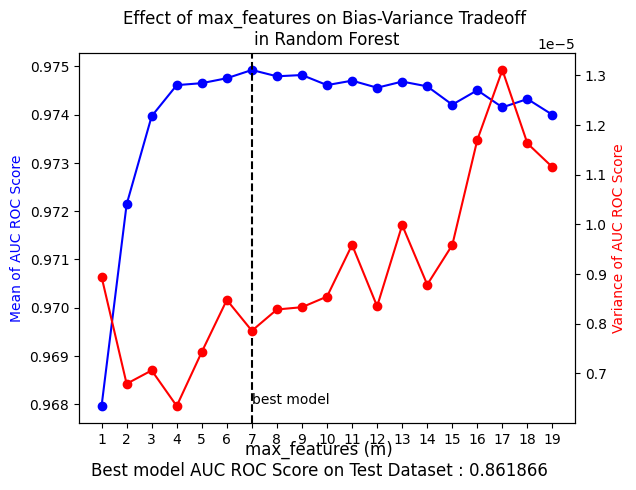

In [47]:
# plot the result
fig, ax1 = plt.subplots()
# plot bias
ax1.plot(list(range(1,X.shape[1] + 1,1)), result_bias,marker='o', color = "blue")
# create a vertical line and annotation of our best m
plt.axvline(results["rank_test_score"].argmin()+1,color="black",linestyle="--")
plt.text(results["rank_test_score"].argmin()+1,0.968,'best model')
plt.ylabel('Mean of AUC ROC Score',color="blue")

# create second axis
ax2 = ax1.twinx()
# plot variance
ax2.plot(list(range(1,X.shape[1] + 1,1)), result_variance ,marker='o', color = "red")
plt.ylabel('Variance of AUC ROC Score',color="red")

plt.title('Effect of max_features on Bias-Variance Tradeoff \nin Random Forest')

plt.xticks(list(range(1,X.shape[1] + 1,1)))
txt="max_features (m)\nBest model AUC ROC Score on Test Dataset : {:.6f}".format(model_test_roc_auc_score)
plt.figtext(0.5, 0.005, txt, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

Based on our simulation above, we can see that:
- Smaller $m$ yield to high bias (low mean of AUC ROC Score). As the number of $m$ increases, bias tends to be lower (mean of AUC ROC score increases). Although our models performance getting slightly worse after its best $m = 7$.
- Smaller $m$ yield to low variance (lower AUC ROC Score variance). As $m$ increases, variance tends to be higher (variance of AUC ROC score increases). We should note that for $m$ = 1, actually the variance is quite high.
- **The plot above shows bias-variance trade off**. As bias decreases (higher mean of AUC ROC Score), variance increases (higher variance of AUC ROC score).
- Our simulation study will yield better result (consistent to our assumption) with higher number of repetition.
- Our best train model is max_features $m=7$. After we use the model on the test set, we have an AUC ROC Score of 0.86.

# Source

- Hastie, T., Tibshirani, R.,, Friedman, J. (2001). The Elements of Statistical Learning. New York, NY, USA: Springer New York Inc.
- Lo, T.W. (2024). Loan Approval Classification Dataset . Kaggle. https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data. Accessed November 15, 2024.